# Эксперимент по сравнению агентов для анализа взаимодействий сервисов в приложениях с микросервисными архитектурами

In [ ]:
%pip install ollama
%pip install pandas
%pip install matplotlib

In [10]:
import time
import csv
import os
from contextlib import redirect_stdout

from prompts import (
    create_no_codeql_prompt,
    create_codeql_without_patterns_prompt,
    create_codeql_with_patterns_prompt,
)

from agent import run_agent_simple, run_agent_codeql_with_patterns, run_agent_codeql

from agent_helpers import (
    make_project_related_tools,
    list_codeql_queries,
    read_codeql_query_by_name,
    save_codeql_query,
    execute_codeql_query,
    save_and_execute_codeql_query,
    create_and_execute_java_annotation_to_classes_query,
    create_and_execute_java_method_calls_to_classes_query,
    create_and_execute_java_services_dependencies_query,
    create_and_execute_js_dir_to_yaml_query,
)

## Постановка задачи

Вопросы, на которые необходимо ответить в рамках исследования:
1. Какая из реализаций агента, с использованием фреймворка для статического анализа кода CodeQL или без, показывает лучшее время анализа?
2. Какая из реализаций агента порождает более точный и корректный результат?
3. Какое количество контекста используют разные реализации агента для проведения анализа?

## Оборудование

1. Процессор: Apple M5
2. ОЗУ: 24Гб
3. Используемая модель: [qwen3:14b](https://ollama.com/library/qwen3) через Ollama с 32k контекста
4. Версия Python: 3.14.7
5. ОС: macOS Tahoe 26.5

## Описание рассматриваемых вариаций агента

### 1. Без использования CodeQL

Агент, не использующий CodeQL, исследует проект при помощи изучения его файловой структуры и чтения (и последующего анализа) файлов исходного кода. Имеет доступ к трем инструментам, которые может вызывать при помощи паттерна [multi-turn tool calling](https://docs.ollama.com/capabilities/tool-calling#multi-turn-tool-calling-agent-loop):
1. `list_directory`: возвращает содержимое переданной директории
2. `list_dir_structure`: возвращает содержимое переданной директории и всех ее поддиректорий
3. `read_source_file`: возвращает первые 12_000 символов переданного файла исходного кода
   
Ниже представлен промт, использующийся при вызове агента.

In [3]:
print(create_no_codeql_prompt("sample_project"))


        You are an expert in analyzing microservice architecture apps written in Java.

        The project root is sample_project.

        Your task is to determine:
        1. What services are in the application.
        2. What each service does.
        3. How the services interact with each other.
        4. What communication mechanisms are used.

        You can use tools to read source code and inspect directories.
        You have the following tools:

        1. list_directory -- Use it to inspect a directory.
        2. list_dir_structure -- Use it to inspect a directory tree. 
        Do NOT use it on large directories such as the whole project root. Prefer list_directory for the project root.
        3. read_source_file -- Use it to inspect a source/configuration file.

        Start by looking at pom.xml, build.gradle and directory structure.

        Do not guess service names or file names. You MUST discover them by inspecting the project.

        Do not stop after 

### 2. С использованием CodeQL

Агент, использующий CodeQL, исследует проект при помощи выполнения запросов к заранее созданным базам данных. У него есть доступ ко всем инструментам простого агента, но их использование ограничено случаямии, когда информации, полученной при помощи запросов, оказывается недостаточно. 

Работа с запросами происходит через набор заранее заготовленных шаблонов. Такое решение было выбрано из-за нескольких факторов:
1. Наличие шаблонов помогает гарантировать корректность запросов. При отсутствии ограничений модель часто делает синтаксические ошибки в запросах, что серьезно замедляет процесс анализа и делает результат менее качественным
3. Наличие шаблонов позволяет снять с агента необходимость выбирать правильный язык и базу данных. Фактически, он абстрагируется от внутренней логики CodeQL, и смотрит на запросы исключительно как на абстрактное средство получения определенной информации

Недостаток использования шаблонов заключается в значительном уменьшении теоретической гибкости инструмента, но в рамках используемой модели увидеть эту разницу невозможно, так как при получении достаточно большой свободы действий модель не способна сгенерировать качественные запросы.

На данный момент агенту доступны следующие шаблоны:
1. `create_and_execute_java_services_dependencies_query`: возвращает сопоставление названий сервисов и зависимостей, указанных в их конфигурационном файле
2. `create_and_execute_java_annotation_to_classes_query`: возвращает название и место объявления Java-классов, помеченных переданной аннотацией
3. `create_and_execute_java_method_calls_to_classes_query`: возвращает название и место объявления класса, вызывающего переданный метод
4. `create_and_execute_js_dir_to_yaml_query`: возвращает путь до конфигурационного YML-файла переданного сервиса

Ниже представлен промт, использующийся при вызове агента.

In [4]:
print(create_codeql_with_patterns_prompt("sample_project"))


        You are an expert in analyzing Java microservice architectures.

        Your task is to analyze the project located at: sample_project and determine:
        1. What services are in the application.
        2. What each service does.
        3. How the services interact with each other.
        4. What communication mechanisms are used.

        You MUST produce a JSON report describing ALL services/modules and their relationships.

        IMPORTANT: This task is a TOOL-DRIVEN CODE ANALYSIS TASK. You MUST use the provided tools, especially the CodeQL tools. 
        Do not rely only on reasoning from source files.

        You have the following tools:

        1. list_directory -- Use it to inspect a directory.
        2. list_dir_structure -- Use it to inspect a directory tree. Do NOT use it on large directories such as the whole project root. Prefer list_directory for the project root.
        3. read_source_file -- Use it to inspect a source/configuration file.
        4

## Постановка эксперимента

Для эксперимента были использованы пять тестовых проектов, реализующих микросервисную архитектуру:
1. [ecommerce-microservices](https://github.com/ibatulanandjp/ecommerce-microservices) (6 сервисов, ~1300 LOC)
2. [sample-spring-microservices-new](https://github.com/piomin/sample-spring-microservices-new) (6 сервисов, ~2000 LOC)
3. [SpringBootMicroservices](https://github.com/Rapter1990/SpringBootMicroservices) (7 сервисов, ~3200 LOC)
4. [spring-petclinic-microservices](https://github.com/spring-petclinic/spring-petclinic-microservices) (8 сервисов, ~4000 LOC)
5. [piggymetrics](https://github.com/sqshq/piggymetrics) (10 сервисов, ~6300 LOC)

Для каждого из них проводилось по десять запусков каждого из инструментов с замером времени запуска.

In [6]:
def time_only_experiment(project_name: str, project_path: str, agent, tools):
    read_project_file, list_project_directory, list_dir_structure = (
        make_project_related_tools(project_path)
    )
    tools.append(read_project_file)
    tools.append(list_project_directory)
    tools.append(list_dir_structure)
    print(tools)

    start = time.perf_counter()
    agent(project_path, tools)
    end = time.perf_counter()

    est_time = end - start
    return est_time

In [66]:
home_dir = ""
projects = [
    ("spring-petclinic-microservices", f"{home_dir}/spring-petclinic-microservices"),
    ("piggymetrics", f"{home_dir}/piggymetrics"),
    ("ecommerce-microservices", f"{home_dir}/ecommerce-microservices"),
    ("sample-spring-microservices-new", f"{home_dir}/sample-spring-microservices-new"),
    ("SpringBootMicroservices", f"{home_dir}/SpringBootMicroservices"),
]

In [ ]:
# WITHOUT PATTERNS
header = ["project_name", "run_num", "time"]
data = []
tools = []
for proj_name, proj_path in projects:
    for i in range(10):
        est_time = time_only_experiment(proj_name, proj_path, run_agent_simple, tools)
        data.append([proj_name, i, est_time])

file_path = f"{home_dir}/microservices-diagrams/run_agent_simple-exp-time.csv"
file_exists = os.path.exists(file_path)

with open(file_path, "a", encoding="utf-8", newline="") as time_res:
    writer = csv.writer(time_res)
    if not file_exists:
        writer.writerow(header)
    writer.writerows(data)

In [ ]:
# WITH PATTERNS
header = ["project_name", "run_num", "time"]
data = []
tools = [
    create_and_execute_java_annotation_to_classes_query,
    create_and_execute_java_method_calls_to_classes_query,
    create_and_execute_java_services_dependencies_query,
    create_and_execute_js_dir_to_yaml_query,
]
for proj_name, proj_path in projects:
    for i in range(10):
        java_db_path = f"{home_dir}/microservices-diagrams/codeql-dbs/{proj_name}-java"
        js_db_path = f"{home_dir}/microservices-diagrams/codeql-dbs/{proj_name}-js"
        !codeql database cleanup --cache-cleanup=clear -- {java_db_path}
        !codeql database cleanup --cache-cleanup=clear -- {js_db_path}

        est_time = time_only_experiment(
            proj_name, proj_path, run_agent_codeql_with_patterns, tools
        )
        data.append([proj_name, i, est_time])

file_path = (
    f"{home_dir}/microservices-diagrams/run_agent_codeql_with_patterns-exp-time.csv"
)
file_exists = os.path.exists(file_path)

with open(file_path, "a", encoding="utf-8", newline="") as time_res:
    writer = csv.writer(time_res)
    if not file_exists:
        writer.writerow(header)
    writer.writerows(data)

                                      simple  with CodeQL patterns
project_name                                                      
SpringBootMicroservices          1056.475637            705.590047
ecommerce-microservices           725.353435            601.438273
piggymetrics                      617.719806            630.894202
sample-spring-microservices-new   724.210540            584.094847
spring-petclinic-microservices    640.198553            612.574548


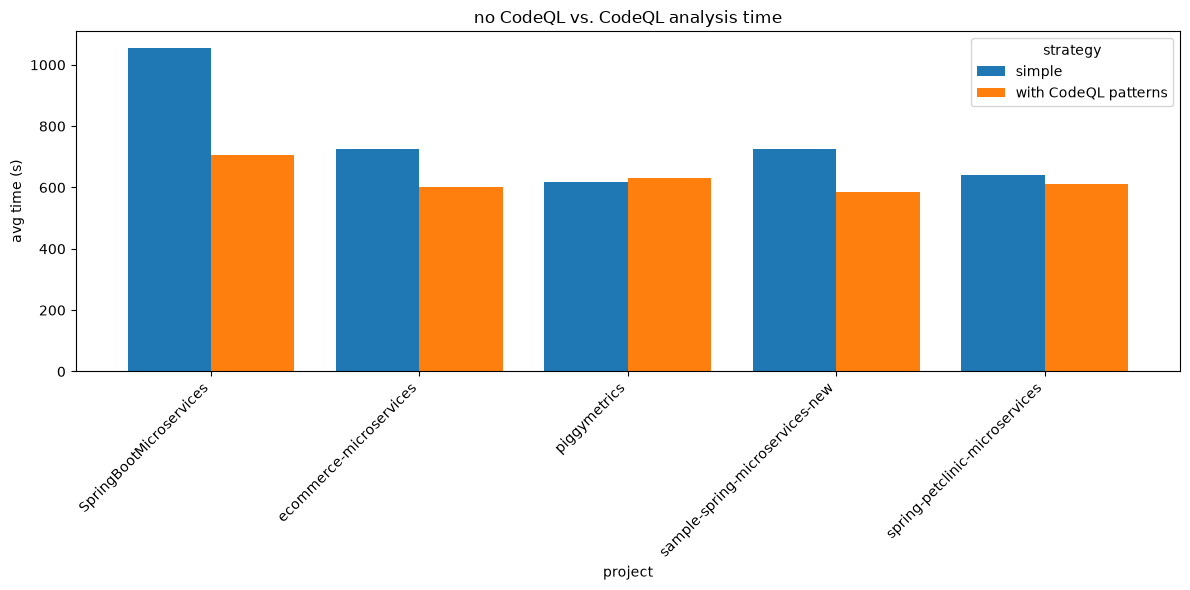

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

df1 = pd.read_csv("run_agent_simple-exp-time.csv")
df2 = pd.read_csv("run_agent_codeql_with_patterns-exp-time.csv")

mean_simple = df1.groupby("project_name")["time"].mean().rename("simple")

mean_codeql = df2.groupby("project_name")["time"].mean().rename("with CodeQL patterns")

comparison = pd.concat([mean_simple, mean_codeql], axis=1)

print(comparison)

ax = comparison.plot(kind="bar", figsize=(12, 6), width=0.8)

plt.xlabel("project")
plt.ylabel("avg time (s)")
plt.title("no CodeQL vs. CodeQL analysis time")

plt.xticks(rotation=45, ha="right")
plt.legend(title="strategy")

plt.tight_layout()
plt.show()

## Промежуточный анализ результатов

При текущих параметрах агент с использованием CodeQL справляется значительно лучше на маленьких проектах (<= 4000 LOC), на больших начинает уступать по скорости. 

Далее необходимо измерить точность результатов анализа и количество потребляемого контекста.

## Приложение: агент с использованием CodeQL без реализации шаблонов запросов

В рамках изначальной идеи модель должна была самостоятельно генерировать запросы, сохранять их в директорию, соответствующую языку (в которую помещен конфигурационный файл `qlpack.yml` для этого языка), и вызывать от соответствующей базы данных. Набор инструментов, помимо уже описанных инструментов для простого агента, был следующим:
1. `save_codeql_query`: сохранить запрос
2. `execute_codeql_query`: исполнить запрос
3. `list_codeql_queries`: просмотреть список доступных запросов, которые можно использовать, как образец
4. `read_codeql_query_by_name`: просмотреть текст запроса-образца

Последние два инструмента были добавлены как попытка дать агенту возможность ориентироваться на корректные запросы при генерации собственных, однако, никаких качественных изменений от их добавления не произошло.